In [1]:
from pathlib import Path
import sys
import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum
from MyModels.MasterPendulum.pendulum_ode import PendulumODE

In [2]:
master = FEMPendulum('Master')
master.initialize(0.0)
mass = master.mass
length = master._equivalent_length
inertia = master.inertia

In [3]:
fmu_path = Path.cwd().parent / 'FMUs/Pendulum.fmu'

In [4]:
eqb_pendulum = FMUComponent(
    name="EQB_Pendulum",
    fmu_path=fmu_path)

In [5]:
eqb_pendulum.parameters['L'].start = length
eqb_pendulum.parameters['inertia'].start = inertia
eqb_pendulum.parameters['m'].start = mass
eqb_pendulum.parameters['q0'].start = np.deg2rad(20)
eqb_pendulum.initialize(0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [6]:
# parameters = eqb_pendulum.parameters
# parameters['L'].start = length
# parameters['inertia'].start = inertia
# parameters['m'].start = mass
# parameters['inertia'].start = inertia
# parameters['q0'].start = np.deg2rad(20)
# eqb_pendulum.set_parameters(**parameters)

In [7]:
eqb_pendulum.initialize(0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [8]:
t_start = 0.0
t_end = 1.0
dt = 0.01
n_steps = int((t_end - t_start) / dt) + 1

for i in range(n_steps):
    t = t_start + i * dt
    eqb_pendulum.do_step(t=t, dt=dt)

In [9]:
history = eqb_pendulum.get_history()

In [10]:
t_vals = history['q']['time']
q_vals = history['q']['values']
omega_vals = history['omega']['values']
alpha_vals = history['alpha']['values']

**Potential Energy**

$$E_{pot} = m \cdot g \cdot L \cdot (1 - \cos(q_0))$$

**Kinetic Energy**
$$E_{kin} = \frac{1}{2} \cdot I \cdot \omega^2$$

**Maximum Angular Velocity at Impact**

$$\omega_{max} = \sqrt{\frac{2 \cdot m \cdot g \cdot L \cdot (1 - \cos(q_0))}{I}}$$

In [11]:
# Theoretical maximum angular velocity at impact (no losses)
g = 9.81
L = master._equivalent_length
m = master.mass
I = master.inertia
q0 = np.deg2rad(20)

omega_max = np.sqrt(2 * m * g * L * (1 - np.cos(q0)) / I)

print(f"Theoretical maximum angular velocity at impact (no losses): {omega_max:.2f} rad/s")

Theoretical maximum angular velocity at impact (no losses): 1.26 rad/s


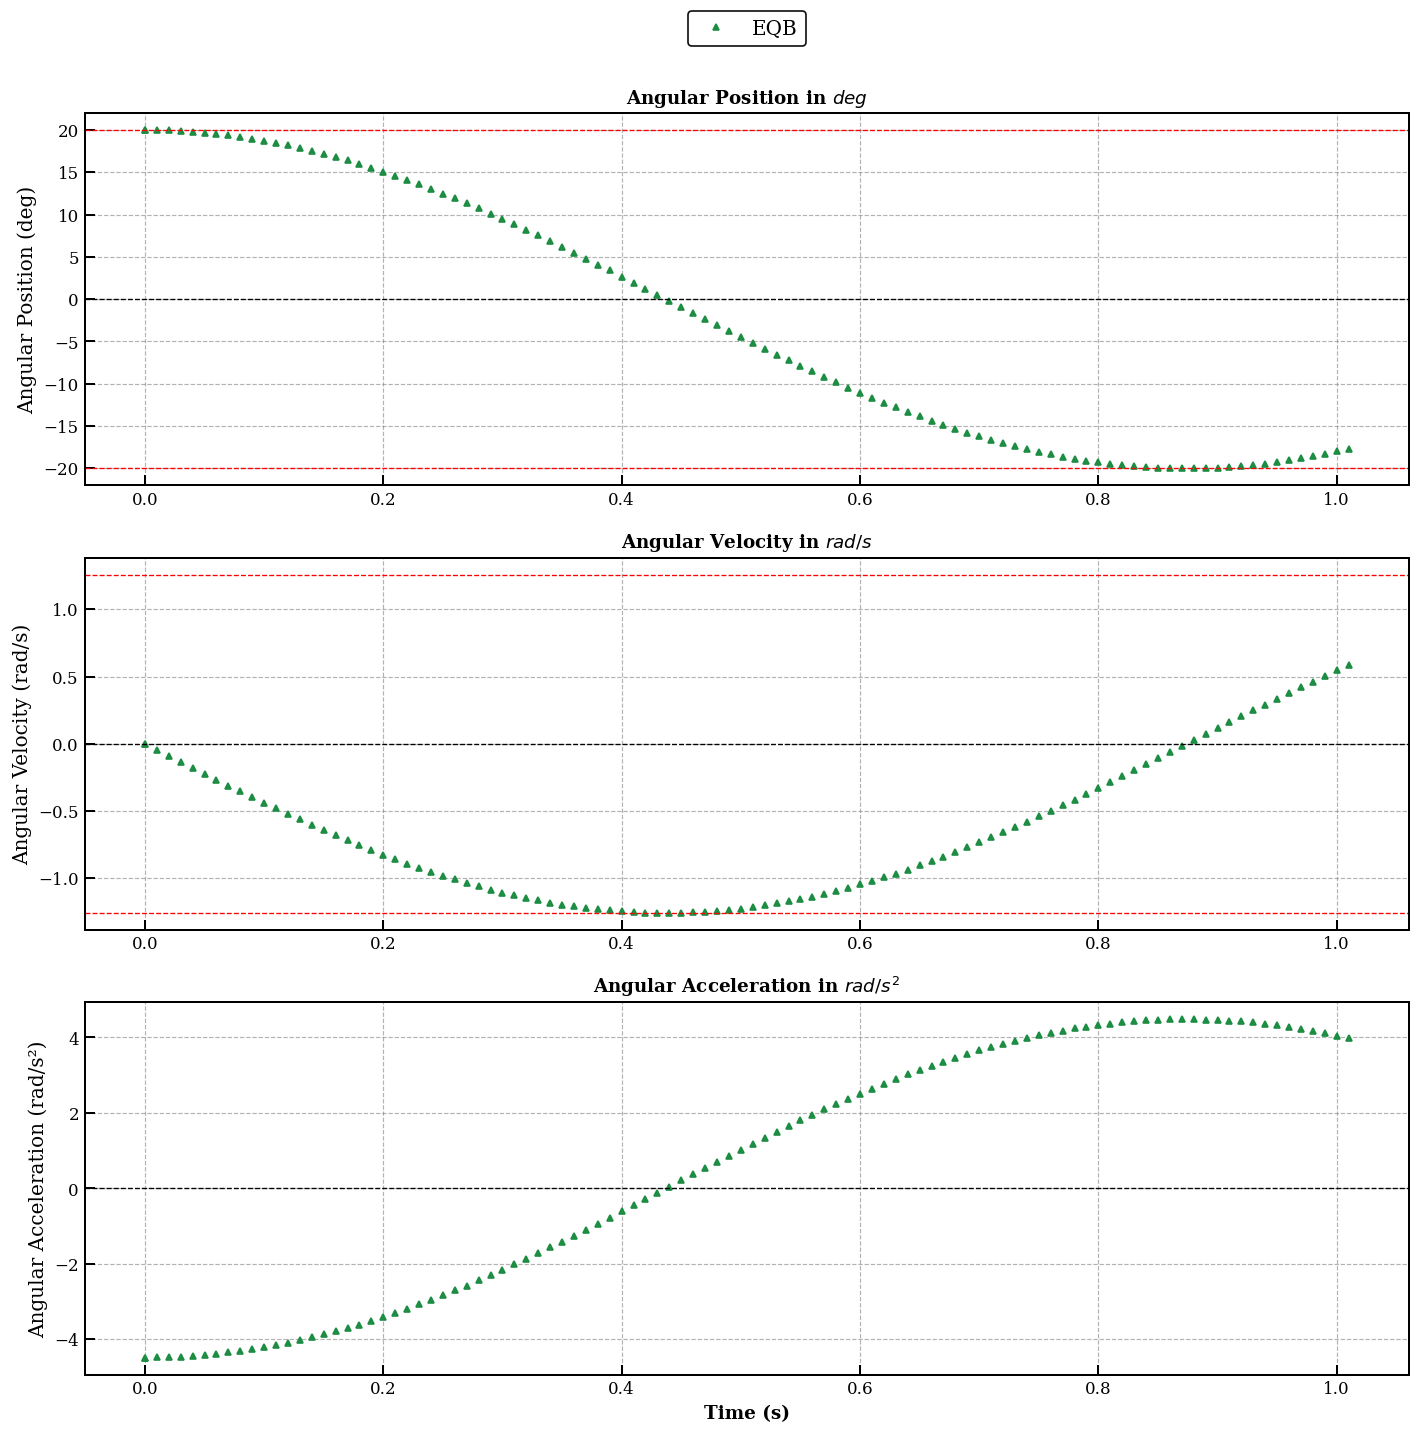

In [12]:
marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5} 
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(12, 12))

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_vals), label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhline(20, color='red', linestyle='--', linewidth=0.8)
plt.axhline(-20, color='red', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_vals, label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.axhline(omega_max, color='red', linestyle='--', linewidth=0.8)
plt.axhline(-omega_max, color='red', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_vals, label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
plt.show()

In [13]:
# Get the old state and values
old_state = eqb_pendulum._instance.getFMUState()
vars_vr = eqb_pendulum._vrs_out_real.values()
old_values = eqb_pendulum._instance.getReal(vars_vr)

# Do some steps
t = eqb_pendulum.t
for i in range(20):
    eqb_pendulum.do_step(t, dt)
    t += dt

# Save the new state and values
new_state = eqb_pendulum._instance.getFMUState()
new_values = eqb_pendulum._instance.getReal(vars_vr)

# Restore the old state and values
eqb_pendulum._instance.setFMUState(old_state)
old_values_2 = eqb_pendulum._instance.getReal(vars_vr)

In [14]:
# Verify FMU state capabilities
print("=== FMU Capability Check ===")
print(f"FMU supports getFMUstate: {eqb_pendulum._md.coSimulation.canGetAndSetFMUstate}")

# Check if FMPy is doing something special
print(f"\nType of 'state' object: {type(old_state)}")
print(f"Old state object: {old_state}")
print(f"New state object: {new_state}")
print(f"Are they the same object? {old_state is new_state}")

# Test if state restoration actually works by checking internal time
print("\n=== Testing State Restoration ===")
print(f"Current FMU time before restoration: {eqb_pendulum.t}")
print(f"Old values: {old_values}")

# Do steps to advance time
t = eqb_pendulum.t
for i in range(5):
    eqb_pendulum.do_step(t, dt)
    t += dt

print(f"Values after steps: {eqb_pendulum._instance.getReal(vars_vr)}")

# Try to restore
eqb_pendulum._instance.setFMUState(old_state)
print(f"FMU time after 'restoration': {eqb_pendulum.t}")
print(f"Values after 'restoration': {eqb_pendulum._instance.getReal(vars_vr)}")



=== FMU Capability Check ===
FMU supports getFMUstate: False

Type of 'state' object: <class 'ctypes.c_void_p'>
Old state object: c_void_p(302609744)
New state object: c_void_p(304387136)
Are they the same object? False

=== Testing State Restoration ===
Current FMU time before restoration: 1.2100000000000002
Old values: [3.9813352890312528, 0.5849719457682464, -0.30864276597823104]
Values after steps: [0.8454302870998507, 1.2354191265420094, -0.06454900886796963]
FMU time after 'restoration': 1.2600000000000002
Values after 'restoration': [3.9813352890312528, 0.5849719457682464, -0.30864276597823104]
